In [1]:
# Install (run once if needed)
# !pip install rasterio numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Load your CSV (change name accordingly)
df = pd.read_csv(r"C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\Hybd_BuiltUp_Area_FIXED.csv")

print(df)

   system:index  BuiltUp_km2  BuiltUp_percent  Year  \
0             0   937.608851        21.318183  2000   
1             1  1178.098725        26.786142  2010   
2             2  1547.950028        35.195360  2020   
3             3  1866.418629        42.436303  2025   

                                     .geo  
0  {"type":"MultiPoint","coordinates":[]}  
1  {"type":"MultiPoint","coordinates":[]}  
2  {"type":"MultiPoint","coordinates":[]}  
3  {"type":"MultiPoint","coordinates":[]}  


In [3]:
years = df['Year'].values.reshape(-1, 1)
built_percent = df['BuiltUp_percent'].values

lr_model = LinearRegression()
lr_model.fit(years, built_percent)

pred_2030_lr = lr_model.predict([[2030]])[0]

print("Linear Regression Prediction (2030):", pred_2030_lr)

Linear Regression Prediction (2030): 44.82207395114324


In [4]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(years, built_percent)

pred_2030_rf = rf_model.predict([[2030]])[0]

print("Random Forest Prediction (2030):", pred_2030_rf)

Random Forest Prediction (2030): 39.747784123284085


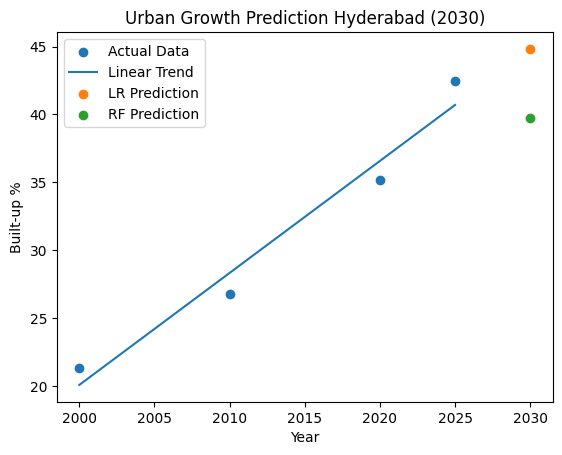

In [5]:
plt.figure()

plt.scatter(years, built_percent, label="Actual Data")
plt.plot(years, lr_model.predict(years), label="Linear Trend")
plt.scatter(2030, pred_2030_lr, label="LR Prediction")
plt.scatter(2030, pred_2030_rf, label="RF Prediction")

plt.xlabel("Year")
plt.ylabel("Built-up %")
plt.title("Urban Growth Prediction Hyderabad (2030)")
plt.legend()

plt.show()

In [6]:
# ---- Load images ----
img2000 = rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2000_Hybd.tif').read(1)
img2010 = rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2010_Hybd.tif').read(1)
img2020 = rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2020_Hybd.tif').read(1)
img2025 = rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2025_Hybd.tif').read(1)




# ---- Fix shape mismatch ----
min_rows = min(img2000.shape[0], img2010.shape[0], img2020.shape[0], img2025.shape[0])
min_cols = min(img2000.shape[1], img2010.shape[1], img2020.shape[1], img2025.shape[1])

def crop(img):
    return img[:min_rows, :min_cols]

img2000 = crop(img2000)
img2010 = crop(img2010)
img2020 = crop(img2020)
img2025 = crop(img2025)

# ---- Stack ----
stack = np.stack([img2000, img2010, img2020, img2025])
years = np.array([2000, 2010, 2020, 2025])


In [7]:
mean_year = np.mean(years)
mean_pixel = np.mean(stack, axis=0)

numerator = np.sum((years[:, None, None] - mean_year) * (stack - mean_pixel), axis=0)
denominator = np.sum((years - mean_year)**2)

slope = numerator / denominator
intercept = mean_pixel - slope * mean_year

prediction_2030 = slope * 2030 + intercept

In [8]:
# Remove invalid values
prediction_2030 = np.clip(prediction_2030, 0, 1)

In [10]:
with rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2000_Hybd.tif') as src:
    profile = src.profile

profile.update(dtype=rasterio.float32)

with rasterio.open('Built_2030.tif', 'w', **profile) as dst:
    dst.write(prediction_2030.astype(rasterio.float32), 1)

print("Saved: Built_2030.tif")

Saved: Built_2030.tif


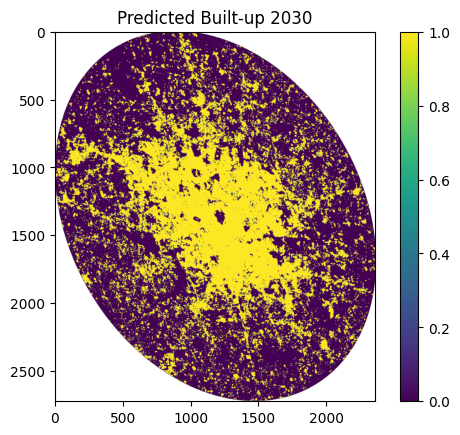

In [11]:
plt.imshow(prediction_2030)
plt.title("Predicted Built-up 2030")
plt.colorbar()
plt.show()

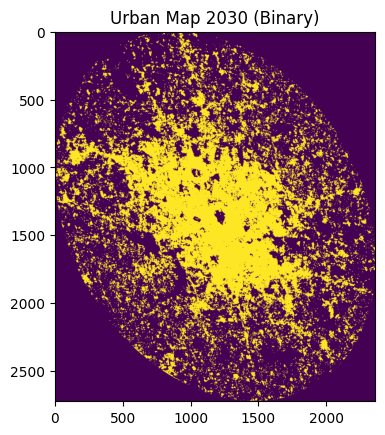

In [12]:
# Threshold (adjust if needed)
urban_2030 = (prediction_2030 > 0.5).astype(int)

plt.imshow(urban_2030)
plt.title("Urban Map 2030 (Binary)")
plt.show()

2000 mean: nan
2010 mean: nan
2020 mean: nan
2025 mean: nan


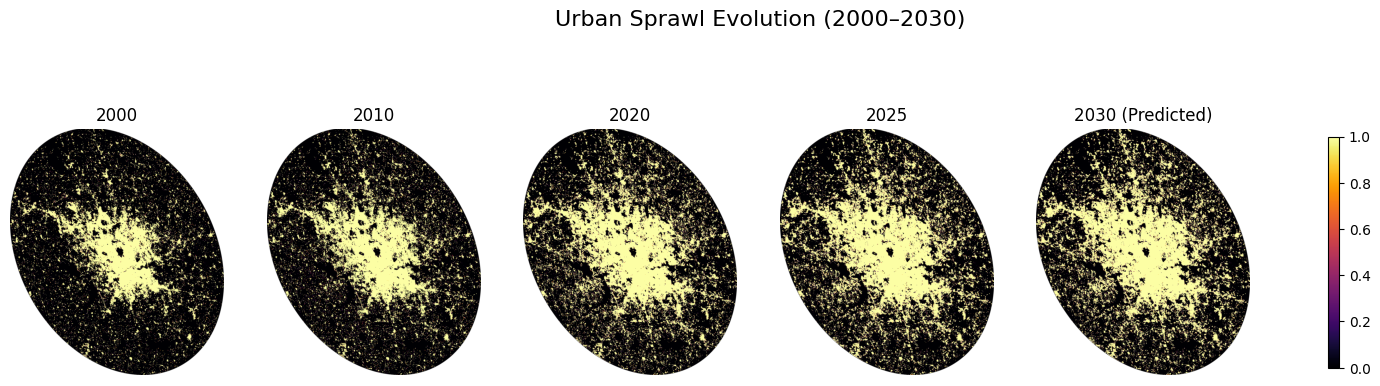

In [13]:
import matplotlib.pyplot as plt

# ---- Load images ----
img2000 = rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2000_Hybd.tif').read(1)
img2010 = rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2010_Hybd.tif').read(1)
img2020 = rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2020_Hybd.tif').read(1)
img2025 = rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2025_Hybd.tif').read(1)

img2030 = prediction_2030

# ---- Plot all in one row ----
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

titles = ['2000', '2010', '2020', '2025', '2030 (Predicted)']
images = [img2000, img2010, img2020, img2025, img2030]
print("2000 mean:", np.mean(img2000))
print("2010 mean:", np.mean(img2010))
print("2020 mean:", np.mean(img2020))
print("2025 mean:", np.mean(img2025))
for i in range(5):
    im = axes[i].imshow(images[i], vmin=0, vmax=1, cmap='inferno')
    axes[i].set_title(titles[i])
    axes[i].axis('off')

# ---- Common colorbar ----
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)

plt.suptitle("Urban Sprawl Evolution (2000–2030)", fontsize=16)
plt.show()

In [14]:
def to_binary(img):
    return (img > 0.2).astype(int)

imgs = [
    to_binary(img2000),
    to_binary(img2010),
    to_binary(img2020),
    to_binary(img2025),
    to_binary(img2030)
]

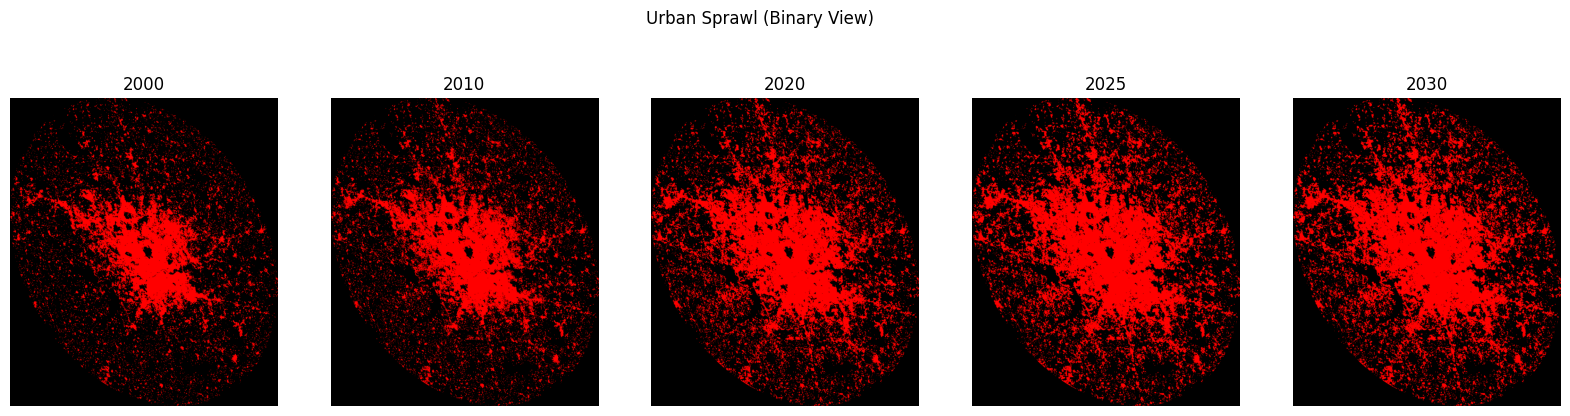

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(20,5))

titles = ['2000','2010','2020','2025','2030']

from matplotlib.colors import ListedColormap

cmap = ListedColormap(['black', 'red'])

for i in range(5):
    axes[i].imshow(imgs[i], cmap=cmap)  # black/white
    axes[i].set_title(titles[i])
    axes[i].axis('off')

plt.suptitle("Urban Sprawl (Binary View)")
plt.show()

In [19]:
import rasterio
import numpy as np

# ---- Load images ----
img2000 = rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2000_Hybd.tif').read(1)
img2010 = rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2010_Hybd.tif').read(1)
img2020 = rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2020_Hybd.tif').read(1)
img2025 = rasterio.open(r'C:\Users\aryaa\Desktop\URBAN SPRAWL MONITORING\Implementation\datasets\img\Built_2025_Hybd.tif').read(1)


# Fix shape mismatch
min_rows = min(img2000.shape[0], img2010.shape[0], img2020.shape[0], img2025.shape[0])
min_cols = min(img2000.shape[1], img2010.shape[1], img2020.shape[1], img2025.shape[1])

def crop(img):
    return img[:min_rows, :min_cols]

img2000 = crop(img2000)
img2010 = crop(img2010)
img2020 = crop(img2020)
img2025 = crop(img2025)

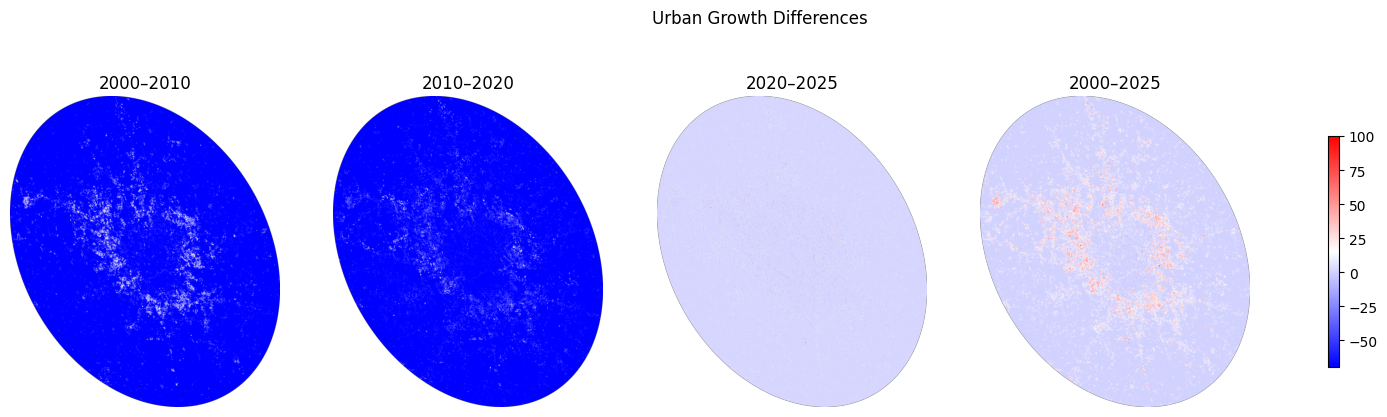

In [20]:

growth_2000_2010 = img2010 - img2000
growth_2010_2020 = img2020 - img2010
growth_2020_2025 = img2025 - img2020
growth_2000_2025 = img2025 - img2000



fig, axes = plt.subplots(1, 4, figsize=(20,5))

growth_maps = [
    img2010 - img2000,
    img2020 - img2010,
    img2025 - img2020,
    img2025 - img2000
]

titles = [
    "2000–2010",
    "2010–2020",
    "2020–2025",
    "2000–2025"
]

for i in range(4):
    im = axes[i].imshow(growth_maps[i], cmap='bwr')
    axes[i].set_title(titles[i])
    axes[i].axis('off')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
plt.suptitle("Urban Growth Differences")
plt.show()

In [28]:
new_urban_2000_2010 = (img2010 > 0.2) & (img2000 <= 0.2)
new_urban_2010_2020 = (img2020 > 0.2) & (img2010 <= 0.2)
new_urban_2020_2025 = (img2025 > 0.2) & (img2020 <= 0.2)


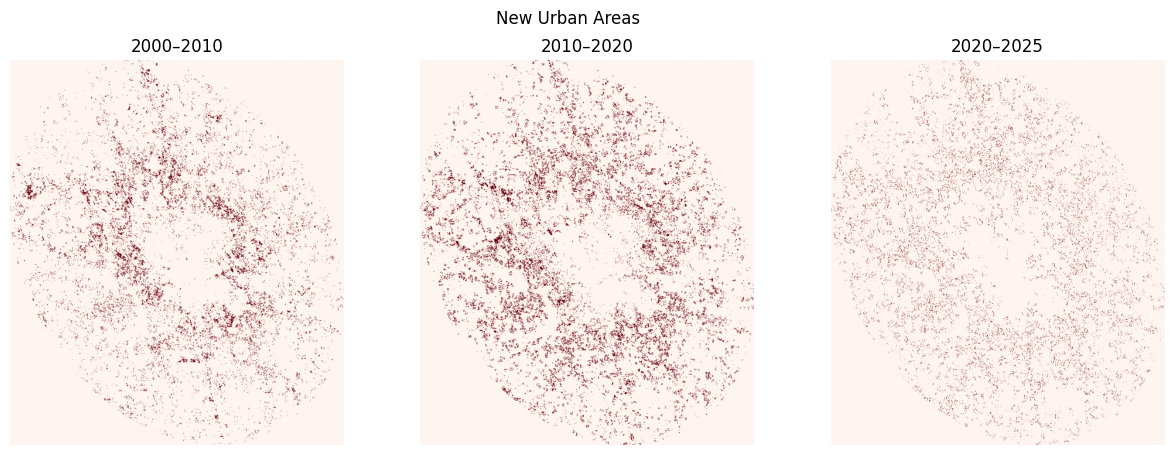

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

maps = [
    new_urban_2000_2010,
    new_urban_2010_2020,
    new_urban_2020_2025
]

titles = ["2000–2010", "2010–2020", "2020–2025"]

for i in range(3):
    axes[i].imshow(maps[i], cmap='Reds')
    axes[i].set_title(titles[i])
    axes[i].axis('off')

plt.suptitle("New Urban Areas")
plt.show()

In [30]:
pixel_area_km2 = (30 * 30) / 1e6  # 30m resolution

def compute_area_change(img_old, img_new, label):
    
    old_urban = (img_old > 0.2)
    new_urban = (img_new > 0.2)
    
    # New urban pixels
    new_growth = (new_urban & (~old_urban))
    
    # Lost urban (optional)
    loss = (old_urban & (~new_urban))
    
    new_area = np.sum(new_growth) * pixel_area_km2
    loss_area = np.sum(loss) * pixel_area_km2
    
    print(f"{label}")
    print("New Urban Area (km²):", new_area)
    print("Lost Urban Area (km²):", loss_area)
    print("Net Change (km²):", new_area - loss_area)
    print("-------------")

# Run for all periods
compute_area_change(img2000, img2010, "2000–2010")
compute_area_change(img2010, img2020, "2010–2020")
compute_area_change(img2020, img2025, "2020–2025")
compute_area_change(img2000, img2025, "2000–2025")

2000–2010
New Urban Area (km²): 241.93349999999998
Lost Urban Area (km²): 0.0
Net Change (km²): 241.93349999999998
-------------
2010–2020
New Urban Area (km²): 372.1329
Lost Urban Area (km²): 0.0
Net Change (km²): 372.1329
-------------
2020–2025
New Urban Area (km²): 161.3493
Lost Urban Area (km²): 25.941599999999998
Net Change (km²): 135.4077
-------------
2000–2025
New Urban Area (km²): 761.7726
Lost Urban Area (km²): 12.298499999999999
Net Change (km²): 749.4741
-------------


In [31]:
new_urban_2025_2030 = (img2030 > 0.5) & (img2025 <= 0.2)
lost_urban_2025_2030 = (img2025 > 0.2) & (img2030 <= 0.5)

pixel_area_km2 = (30 * 30) / 1e6  # 30m resolution

new_area_2030 = np.sum(new_urban_2025_2030) * pixel_area_km2
lost_area_2030 = np.sum(lost_urban_2025_2030) * pixel_area_km2

print("2025–2030 (Predicted)")
print("New Urban Area (km²):", new_area_2030)
print("Lost Urban Area (km²):", lost_area_2030)
print("Net Change (km²):", new_area_2030 - lost_area_2030)

2025–2030 (Predicted)
New Urban Area (km²): 15.7653
Lost Urban Area (km²): 75.5829
Net Change (km²): -59.8176


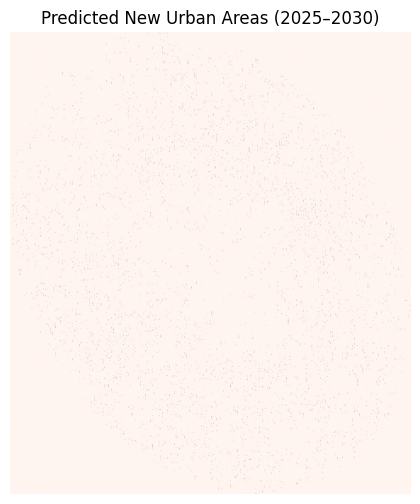

In [32]:
plt.figure(figsize=(6,6))
plt.imshow(new_urban_2025_2030, cmap='Reds')
plt.title("Predicted New Urban Areas (2025–2030)")
plt.axis('off')
plt.show()

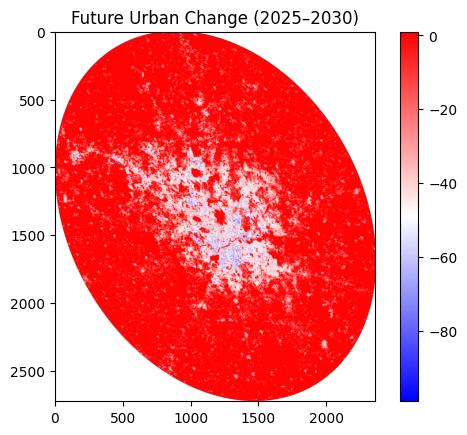

In [33]:
future_change = img2030 - img2025

plt.imshow(future_change, cmap='bwr')
plt.title("Future Urban Change (2025–2030)")
plt.colorbar()
plt.show()